# Dimensionality Reduction Techniques

In this notebook, we'll explore various dimensionality reduction techniques that are essential in machine learning and data analysis. We'll cover:

1. The Curse of Dimensionality
2. Principal Component Analysis (PCA)
3. Linear Discriminant Analysis (LDA)
4. t-distributed Stochastic Neighbor Embedding (t-SNE)

All examples will use simple datasets and beginner-friendly code.

## What is Dimensionality Reduction?

**Dimensionality reduction** is the process of reducing the number of features (dimensions) in a dataset while preserving as much information as possible.

### Why Reduce Dimensions?
1. **Visualization**: Humans can only visualize 2-3 dimensions
2. **Computational Efficiency**: Fewer dimensions mean faster algorithms
3. **Avoid Overfitting**: Simpler models often generalize better
4. **Remove Noise**: Filtering out unimportant dimensions can improve results

Think of it like compressing a large image file - you keep the important details while making it much smaller!

## 1. Import Required Libraries

First, let's import the libraries we'll need for our analysis:

In [18]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For creating example datasets
from sklearn import datasets

# Dimensionality reduction techniques
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE

# For preprocessing and model evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Set the style for our plots
plt.style.use('seaborn-v0_8')  # Using a valid matplotlib style that mimics seaborn
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# For reproducibility
np.random.seed(42)

## 2. Load and Prepare a Dataset

For our examples, we'll use the famous Iris dataset, which contains measurements for 150 iris flowers from three different species. This dataset is perfect for beginners as it's small, clean, and has just 4 dimensions (features).

### Understanding the Dataset

When working with dimensionality reduction, it's important to first understand our data:

- **What are the features?** In this case, measurements of iris flowers (sepal length, sepal width, etc.)
- **How many dimensions?** 4 features = 4 dimensions
- **Are there classes?** Yes, 3 different iris species

Even though 4 dimensions isn't that high, it's still difficult to visualize all at once. This is where dimensionality reduction comes in!

In [19]:
# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Create a DataFrame for easier data handling
df = pd.DataFrame(data=X, columns=feature_names)
df['target'] = y
df['target_name'] = [target_names[i] for i in y]

# Display the first few rows of the dataset
print(f"Dataset shape: {X.shape} - {X.shape[0]} samples, {X.shape[1]} features")
print("\nFeature names:", feature_names)
print("\nTarget classes:", target_names)
print("\nSample data:")
df.head()

Dataset shape: (150, 4) - 150 samples, 4 features

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target classes: ['setosa' 'versicolor' 'virginica']

Sample data:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


<Figure size 1200x1000 with 0 Axes>

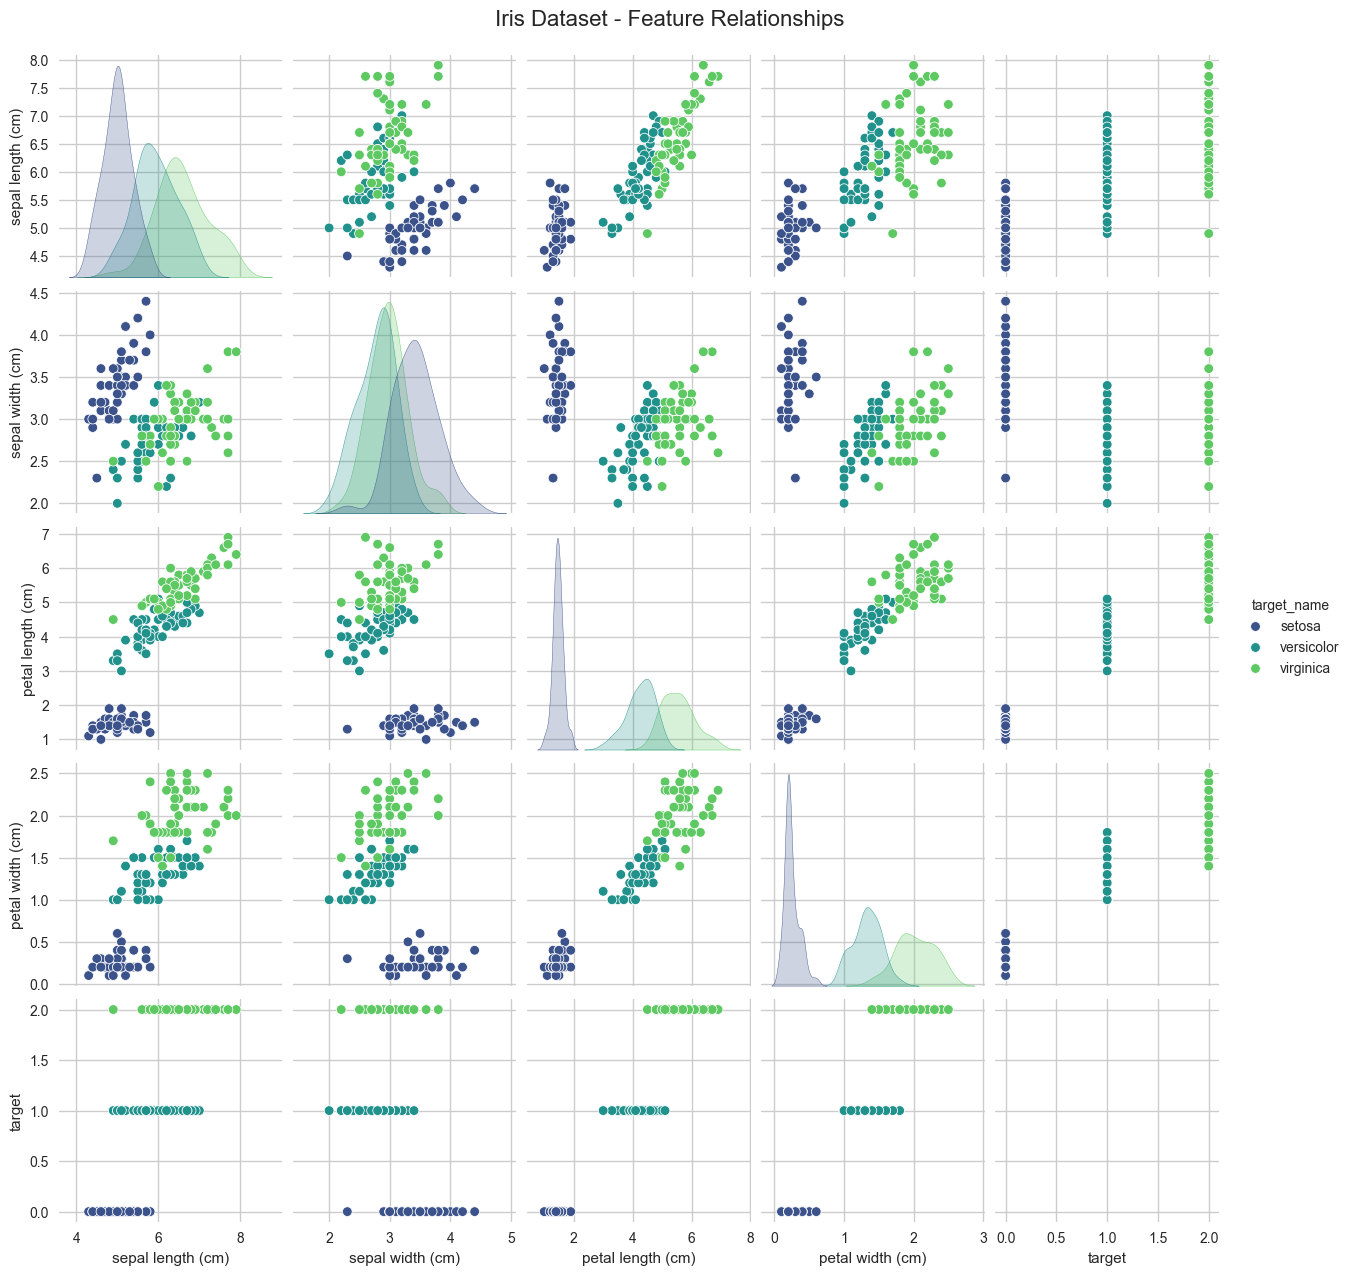

In [20]:
# Let's visualize the dataset with a pair plot to see the feature relationships
plt.figure(figsize=(12, 10))
sns.pairplot(df, hue='target_name', palette='viridis')
plt.suptitle('Iris Dataset - Feature Relationships', y=1.02, fontsize=16)
plt.show()

In [21]:
# Scale the data (important for dimensionality reduction techniques)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create a scaled DataFrame for reference
df_scaled = pd.DataFrame(data=X_scaled, columns=feature_names)
print("First 5 rows of scaled data:")
df_scaled.head()

First 5 rows of scaled data:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


## 3. The Curse of Dimensionality

The **Curse of Dimensionality** refers to various phenomena that arise when analyzing data in high-dimensional spaces that do not occur in low-dimensional spaces.

Main challenges include:

1. **Increased Sparsity**: As dimensions increase, the available data becomes sparse
2. **Distance Metrics Breakdown**: In high dimensions, distances between points become less meaningful
3. **Computational Complexity**: Algorithms require more time and resources
4. **Overfitting**: Models are more likely to overfit with many dimensions

### Intuition:

Imagine a square (2D) with side length 1. To cover 10% of each dimension, you need to sample 10 points per dimension, for a total of $10^2 = 100$ points.

In 3 dimensions, to maintain the same coverage density, you need $10^3 = 1,000$ points.

In 10 dimensions, you need $10^{10} = 10$ billion points!

### Mathematical Insight:

In high dimensions, the volume of space increases exponentially with the number of dimensions. For a unit hypercube, the volume is $1^n = 1$, but the number of points needed to maintain a given density grows as $(\frac{1}{density})^n$.

Let's demonstrate these issues with some simple examples:

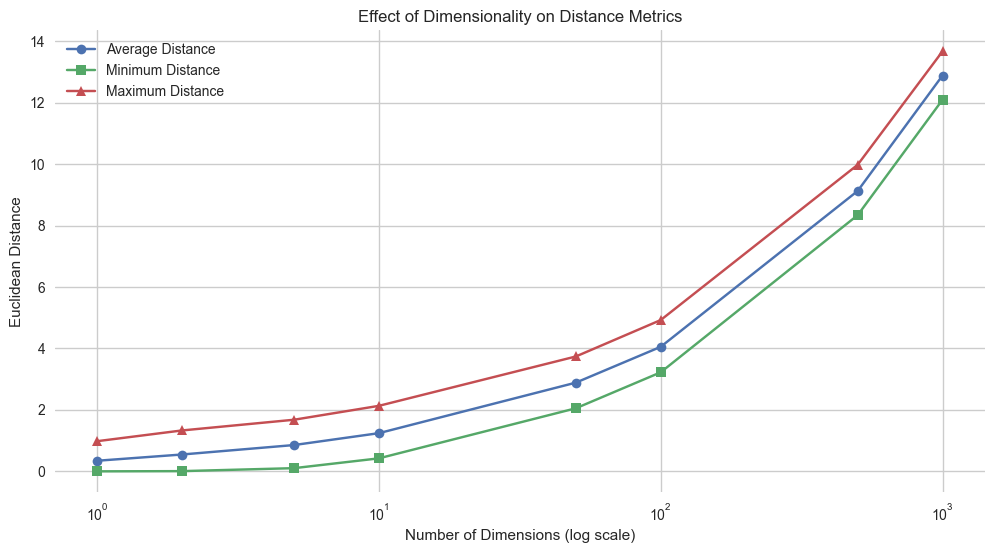

As dimensions increase:
- Minimum distances between points: 0.0000 → 12.0980
- Maximum distances between points: 0.9814 → 13.6750
- Ratio of max/min distance: 40686.5878 → 1.1304

This shows how all points tend to be approximately equidistant in high dimensions!


In [22]:
# Example 1: Demonstrate how distances become less meaningful in higher dimensions

dimensions = [1, 2, 5, 10, 50, 100, 500, 1000]
num_samples = 1000
avg_distances = []
min_distances = []
max_distances = []

for dim in dimensions:
    # Generate random points in a unit hypercube
    points = np.random.random((num_samples, dim))
    
    # Calculate pairwise distances
    distances = []
    for i in range(100):  # Use only 100 points for calculation to save time
        for j in range(i+1, 100):
            dist = np.sqrt(np.sum((points[i] - points[j])**2))
            distances.append(dist)
    
    avg_distances.append(np.mean(distances))
    min_distances.append(np.min(distances))
    max_distances.append(np.max(distances))

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(dimensions, avg_distances, 'o-', label='Average Distance')
plt.plot(dimensions, min_distances, 's-', label='Minimum Distance')
plt.plot(dimensions, max_distances, '^-', label='Maximum Distance')
plt.xscale('log')
plt.xlabel('Number of Dimensions (log scale)')
plt.ylabel('Euclidean Distance')
plt.title('Effect of Dimensionality on Distance Metrics')
plt.legend()
plt.grid(True)
plt.show()

# Print insights
print("As dimensions increase:")
print(f"- Minimum distances between points: {min_distances[0]:.4f} → {min_distances[-1]:.4f}")
print(f"- Maximum distances between points: {max_distances[0]:.4f} → {max_distances[-1]:.4f}")
print(f"- Ratio of max/min distance: {max_distances[0]/min_distances[0]:.4f} → {max_distances[-1]/min_distances[-1]:.4f}")
print("\nThis shows how all points tend to be approximately equidistant in high dimensions!")

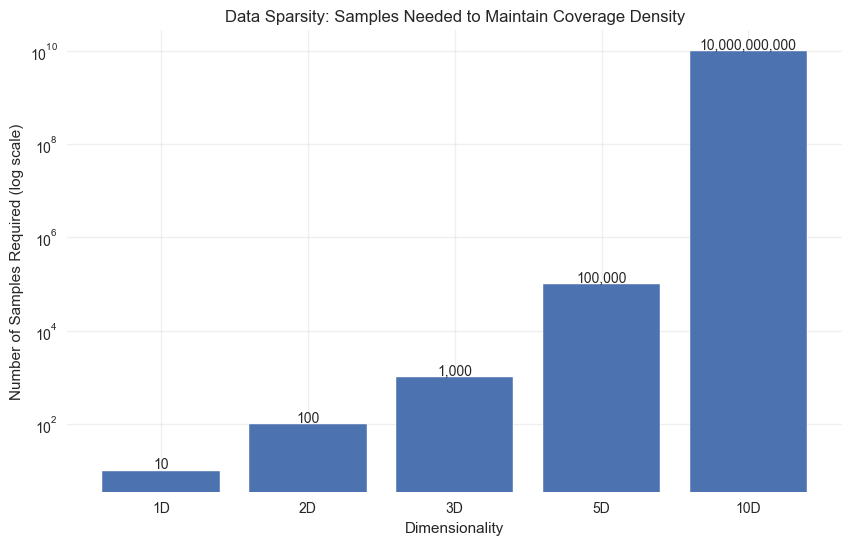

To maintain the same data density with 10% coverage along each dimension:
- 1 dimensions: 10 samples required
- 2 dimensions: 100 samples required
- 3 dimensions: 1,000 samples required
- 5 dimensions: 100,000 samples required
- 10 dimensions: 10,000,000,000 samples required

This exponential growth in required samples is a key aspect of the curse of dimensionality!


In [23]:
# Example 2: Data sparsity in higher dimensions
# Let's see how many samples we need for different dimensions

dimensions = [1, 2, 3, 5, 10]
coverage = 0.1  # We want to cover 10% of each dimension with sample points

samples_needed = []
for dim in dimensions:
    # In a unit hypercube, to achieve the same coverage density,
    # we need exponentially more samples as dimensions increase
    n_samples = int(np.ceil((1/coverage) ** dim))
    samples_needed.append(n_samples)

plt.figure(figsize=(10, 6))
plt.bar(range(len(dimensions)), samples_needed)
plt.xticks(range(len(dimensions)), [f"{d}D" for d in dimensions])
plt.yscale('log')
plt.ylabel('Number of Samples Required (log scale)')
plt.xlabel('Dimensionality')
plt.title('Data Sparsity: Samples Needed to Maintain Coverage Density')
plt.grid(True, alpha=0.3)

for i, v in enumerate(samples_needed):
    plt.text(i, v * 1.1, f"{v:,}", ha='center')

plt.show()

print("To maintain the same data density with 10% coverage along each dimension:")
for d, s in zip(dimensions, samples_needed):
    print(f"- {d} dimensions: {s:,} samples required")
print("\nThis exponential growth in required samples is a key aspect of the curse of dimensionality!")

## 4. Principal Component Analysis (PCA)

**Principal Component Analysis (PCA)** is one of the most popular dimensionality reduction techniques. It works by:

1. Finding directions (principal components) that maximize the variance in the data
2. Projecting the data onto these directions
3. Retaining only the top N components to reduce dimensionality

### Intuition:

Imagine you take photos of a pencil from different angles. The longest view (from the side) captures most of the pencil's shape. The end-on view provides very little information. PCA finds these "best angles" (principal components) to view your high-dimensional data.

### Mathematical Foundation:

1. **Step 1**: Standardize the data (subtract mean, divide by standard deviation)
2. **Step 2**: Calculate the covariance matrix: $C = \frac{1}{n-1}X^TX$ where $X$ is the centered data matrix
3. **Step 3**: Find eigenvectors and eigenvalues of the covariance matrix:
   - Eigenvalues ($\lambda$) tell us the amount of variance in that direction
   - Eigenvectors ($v$) give us the direction of the principal components
4. **Step 4**: Sort eigenvectors by their eigenvalues (largest to smallest)
5. **Step 5**: Project the data onto the top k eigenvectors: $Z = XV_k$ where $V_k$ contains the top k eigenvectors

### Key Benefits:
- **Unsupervised** technique (doesn't need class labels)
- Preserves maximum variance in the data
- Reduces noise
- Helps with visualization and algorithm efficiency

Let's apply PCA to our Iris dataset:

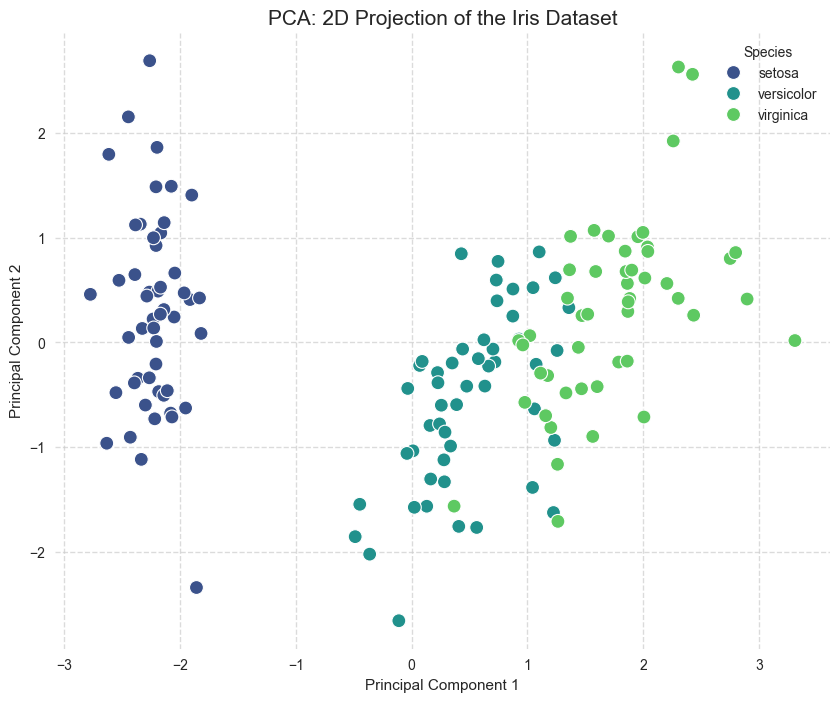

Explained variance ratio by component: [0.72962445 0.22850762]
Total variance explained: 95.81%


In [24]:
# Apply PCA to reduce our data to 2 dimensions (for visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for the PCA-transformed data
pca_df = pd.DataFrame(
    data=X_pca, 
    columns=['Principal Component 1', 'Principal Component 2']
)
pca_df['target'] = y
pca_df['target_name'] = [target_names[i] for i in y]

# Plot the results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1', 
    y='Principal Component 2', 
    hue='target_name',
    palette='viridis',
    s=100,
    data=pca_df
)
plt.title('PCA: 2D Projection of the Iris Dataset', fontsize=15)
plt.grid(linestyle='--', alpha=0.7)
plt.legend(title='Species')
plt.show()

# Print explained variance
print(f"Explained variance ratio by component: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

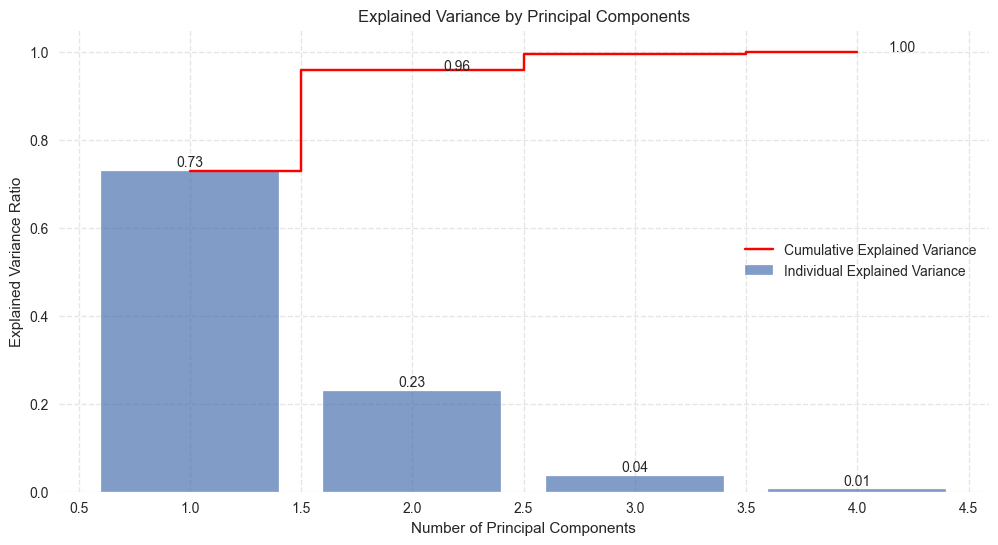

Principal Component Loadings (Feature Importance):
                        PC1       PC2
sepal length (cm)  0.521066  0.377418
sepal width (cm)  -0.269347  0.923296
petal length (cm)  0.580413  0.024492
petal width (cm)   0.564857  0.066942


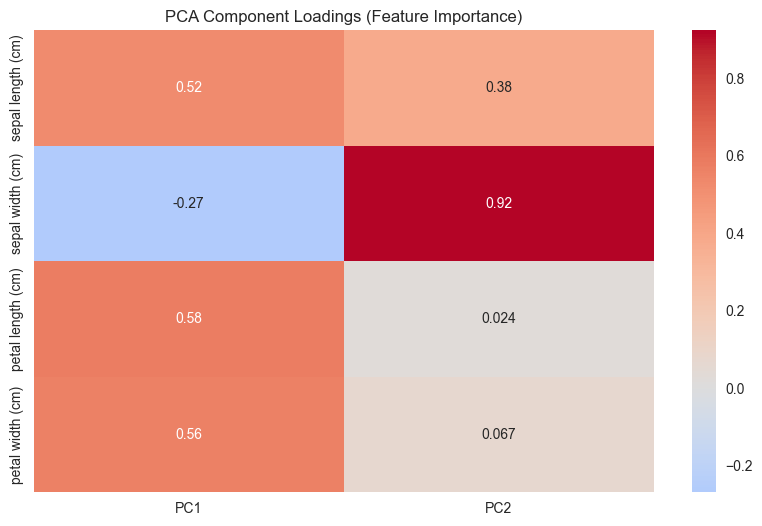

In [25]:
# Let's examine how variance is distributed across all components
pca_full = PCA().fit(X_scaled)

# Plot the explained variance for each component
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1), 
        pca_full.explained_variance_ratio_, 
        alpha=0.7, 
        label='Individual Explained Variance')
plt.step(range(1, len(pca_full.explained_variance_ratio_) + 1), 
         np.cumsum(pca_full.explained_variance_ratio_), 
         where='mid', 
         label='Cumulative Explained Variance',
         color='red')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.grid(linestyle='--', alpha=0.5)
plt.legend()

# Add value labels above the bars
for i, v in enumerate(pca_full.explained_variance_ratio_):
    plt.text(i + 1, v + 0.01, f'{v:.2f}', ha='center')

# Add value labels for cumulative line
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
for i, v in enumerate(cumulative):
    if i % 2 == 1:  # Only label every other point to avoid clutter
        plt.text(i + 1.2, v, f'{v:.2f}', ha='center')

plt.show()

# Let's also look at the loadings/feature importance for each principal component
feature_importance = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(2)],
    index=feature_names
)
print("Principal Component Loadings (Feature Importance):")
print(feature_importance)

# Visualize the loadings
plt.figure(figsize=(10, 6))
sns.heatmap(feature_importance, annot=True, cmap='coolwarm', center=0)
plt.title('PCA Component Loadings (Feature Importance)')
plt.show()

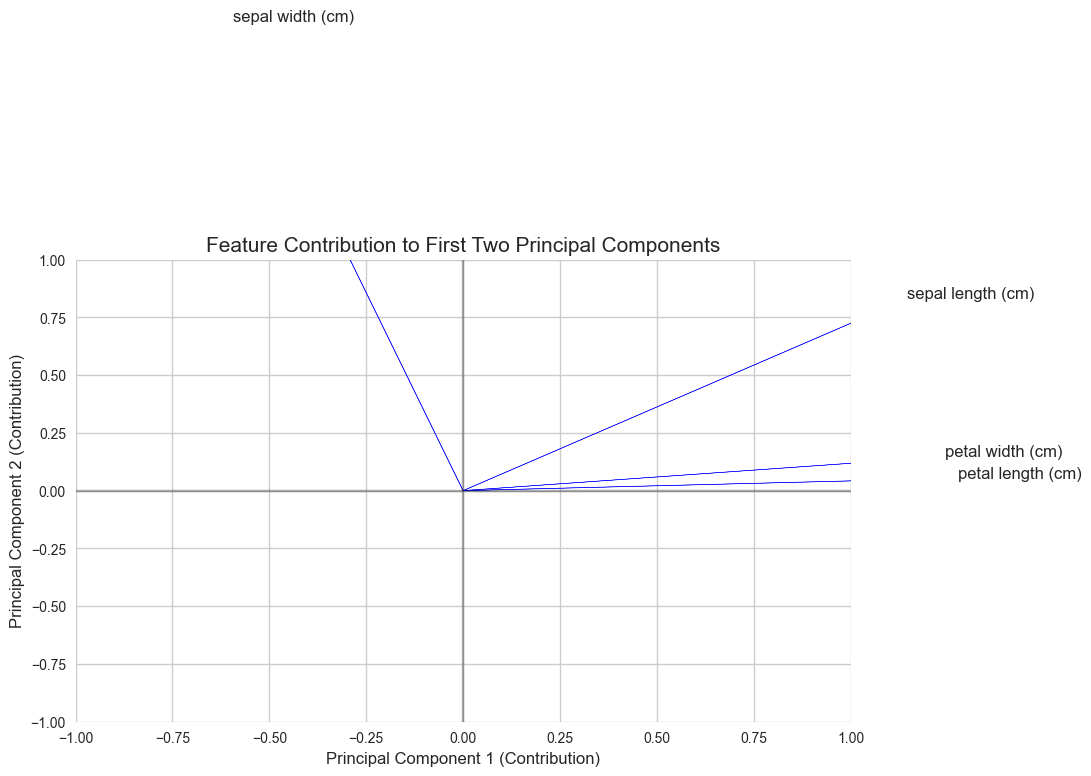

Interpretation of the PCA biplot:
- Arrows show how each original feature contributes to the principal components
- Longer arrows have more influence on that component
- Features pointing in the same direction are positively correlated
- Features pointing in opposite directions are negatively correlated
- Features at right angles are uncorrelated


In [26]:
# Let's see how we can interpret the PCA components
# We'll create a simple visualization showing what each component represents

# Create a dataframe of feature importances for all components
pca_full_components = pd.DataFrame(
    pca_full.components_,
    columns=feature_names
)

# Visualize the first two principal components
plt.figure(figsize=(10, 6))
plt.title('Feature Contribution to First Two Principal Components', fontsize=15)

# For each feature, plot an arrow showing its contribution
for i, feature in enumerate(feature_names):
    plt.arrow(0, 0, pca_full.components_[0, i]*2, pca_full.components_[1, i]*2, 
              head_width=0.05, head_length=0.08, fc='blue', ec='blue')
    plt.text(pca_full.components_[0, i]*2.2, pca_full.components_[1, i]*2.2, feature, fontsize=12)

plt.grid(True)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('Principal Component 1 (Contribution)', fontsize=12)
plt.ylabel('Principal Component 2 (Contribution)', fontsize=12)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.show()

print("Interpretation of the PCA biplot:")
print("- Arrows show how each original feature contributes to the principal components")
print("- Longer arrows have more influence on that component")
print("- Features pointing in the same direction are positively correlated")
print("- Features pointing in opposite directions are negatively correlated")
print("- Features at right angles are uncorrelated")

## 5. Linear Discriminant Analysis (LDA)

**Linear Discriminant Analysis (LDA)** is another dimensionality reduction technique, but unlike PCA, it's **supervised**. LDA focuses on:

1. Maximizing the separation between different classes
2. Minimizing the scatter within each class

### Intuition:

Imagine you have different colored marbles on a table and you want to find the best angle to take a photo so that same-colored marbles appear grouped together and different-colored marbles appear far apart. LDA finds this optimal "viewing angle" that separates the classes most clearly.

### Mathematical Foundation:

1. **Step 1**: Compute the mean vector for each class and the overall mean:
   - Class means: $\mu_c = \frac{1}{n_c}\sum_{i \in class_c} x_i$
   - Overall mean: $\mu = \frac{1}{n}\sum_{i=1}^{n} x_i$

2. **Step 2**: Calculate the scatter matrices:
   - Within-class scatter: $S_W = \sum_{c=1}^{C} \sum_{i \in class_c} (x_i - \mu_c)(x_i - \mu_c)^T$
   - Between-class scatter: $S_B = \sum_{c=1}^{C} n_c(\mu_c - \mu)(\mu_c - \mu)^T$

3. **Step 3**: Find the eigenvectors of $S_W^{-1}S_B$ and sort by eigenvalues
   - The transformation matrix W contains these eigenvectors
   
4. **Step 4**: Project the data onto these directions: $Z = XW$

### Key Differences from PCA:
- LDA uses class labels to find optimal separation
- LDA can be used for classification directly
- LDA can at most reduce to C-1 dimensions (where C is the number of classes)
- PCA maximizes variance, LDA maximizes class separation

Let's apply LDA to our Iris dataset:

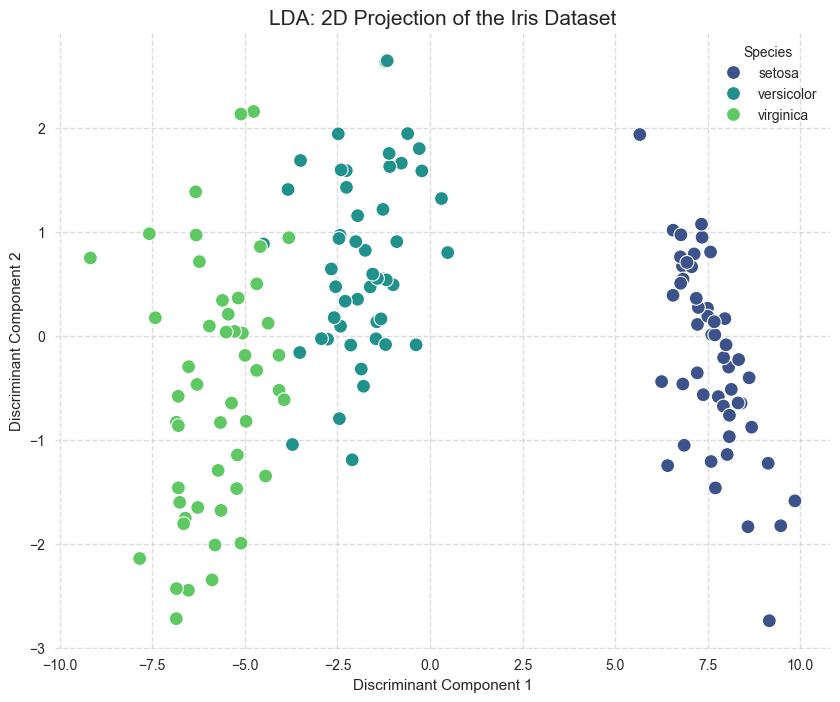

Explained variance ratio by discriminant: [0.9912126 0.0087874]
Total variance explained: 100.00%


In [27]:
# Apply LDA to reduce our data to 2 dimensions (for visualization)
# For Iris, we have 3 classes, so we can reduce to at most 2 dimensions (C-1)
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)  # Note that LDA needs the class labels (y)

# Create a DataFrame for the LDA-transformed data
lda_df = pd.DataFrame(
    data=X_lda, 
    columns=['Discriminant Component 1', 'Discriminant Component 2']
)
lda_df['target'] = y
lda_df['target_name'] = [target_names[i] for i in y]

# Plot the results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Discriminant Component 1', 
    y='Discriminant Component 2', 
    hue='target_name',
    palette='viridis',
    s=100,
    data=lda_df
)
plt.title('LDA: 2D Projection of the Iris Dataset', fontsize=15)
plt.grid(linestyle='--', alpha=0.7)
plt.legend(title='Species')
plt.show()

# Print explained variance
print(f"Explained variance ratio by discriminant: {lda.explained_variance_ratio_}")
print(f"Total variance explained: {sum(lda.explained_variance_ratio_)*100:.2f}%")

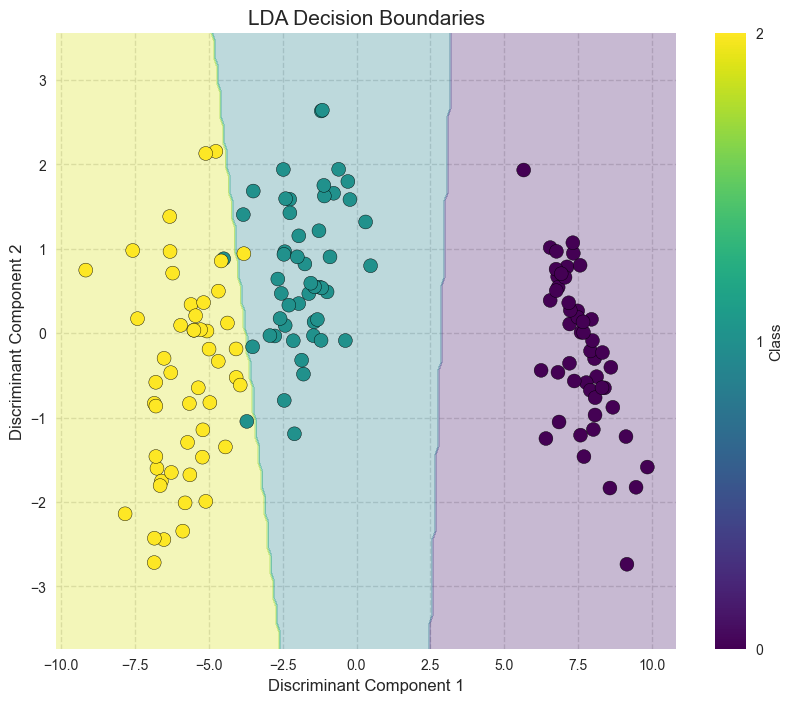

What this visualization shows:
- LDA creates clear decision boundaries between classes
- Points of the same class are clustered together
- The projection maximizes separation between classes


In [28]:
# Let's look at how well LDA separates the classes
# We'll create a plot showing the decision boundaries

# Create a mesh grid to plot the decision boundaries
x_min, x_max = X_lda[:, 0].min() - 1, X_lda[:, 0].max() + 1
y_min, y_max = X_lda[:, 1].min() - 1, X_lda[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Create an LDA classifier
lda_clf = LDA()
lda_clf.fit(X_lda, y)  # Fit directly on the transformed data

# Predict classes directly on the mesh grid in LDA space
Z = lda_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.viridis)
plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap=plt.cm.viridis, s=100, edgecolors='k')
plt.xlabel('Discriminant Component 1', fontsize=12)
plt.ylabel('Discriminant Component 2', fontsize=12)
plt.title('LDA Decision Boundaries', fontsize=15)
plt.colorbar(ticks=[0, 1, 2], label='Class')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

print("What this visualization shows:")
print("- LDA creates clear decision boundaries between classes")
print("- Points of the same class are clustered together")
print("- The projection maximizes separation between classes")

## 6. t-SNE (t-distributed Stochastic Neighbor Embedding)

**t-SNE** is a more modern dimensionality reduction technique designed specifically for visualization of high-dimensional data. Unlike PCA and LDA which are linear, t-SNE is a **non-linear** technique that:

1. Preserves local structure and relationships between points
2. Better captures complex manifolds and clusters in the data
3. Uses probability distributions to map similarities between points

### Intuition:

Imagine a crumpled piece of paper (3D) with drawings on it. If you carefully unfold it onto a table (2D), you can see all the drawings without distorting them too much. t-SNE tries to "unfold" high-dimensional data into 2D or 3D while preserving the relationships between nearby points.

### Mathematical Foundation:

1. **Step 1**: Calculate similarity between points in high-dimensional space using Gaussian distributions:
   - Similarity $p_{j|i} = \frac{exp(-||x_i - x_j||^2/2\sigma_i^2)}{\sum_{k \neq i} exp(-||x_i - x_k||^2/2\sigma_i^2)}$
   - Convert to symmetric probability: $p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$

2. **Step 2**: Calculate similarity between points in low-dimensional space using t-distribution:
   - $q_{ij} = \frac{(1 + ||y_i - y_j||^2)^{-1}}{\sum_{k \neq l} (1 + ||y_k - y_l||^2)^{-1}}$
   
3. **Step 3**: Minimize the difference (KL-divergence) between these distributions:
   - $KL(P||Q) = \sum_i \sum_j p_{ij} \log \frac{p_{ij}}{q_{ij}}$
   - This is minimized using gradient descent

### Key Parameters:
- **Perplexity**: Balance between local and global structure (typical values: 5-50)
   - Think of it as a rough guess about the number of neighbors each point has
- **Learning rate**: How quickly the algorithm progresses
- **Number of iterations**: More iterations for more stable results

Let's apply t-SNE to our Iris dataset:

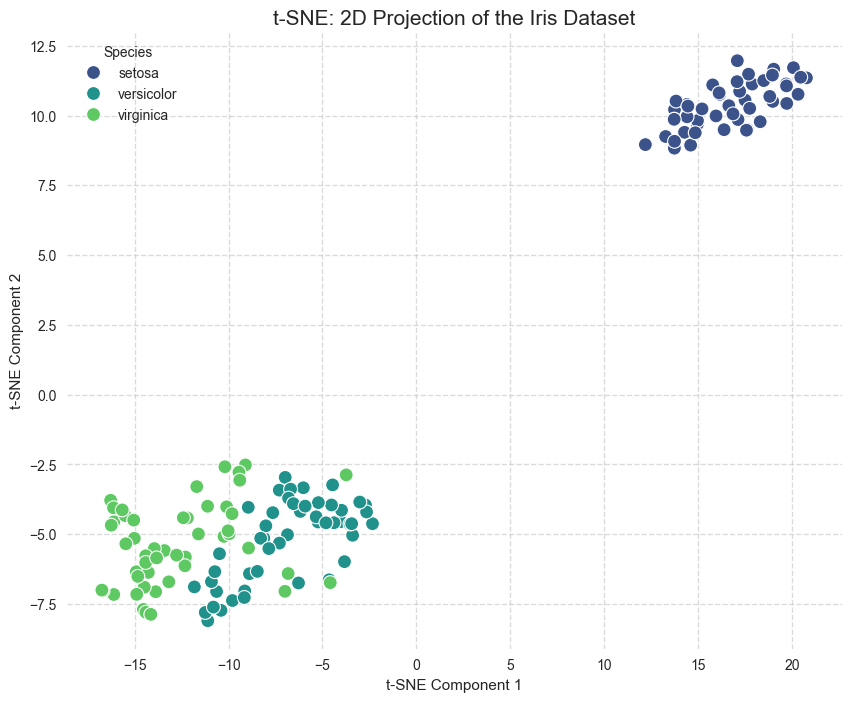

In [29]:
# Apply t-SNE to reduce our data to 2 dimensions
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    n_iter=1000,
    learning_rate=200
)
X_tsne = tsne.fit_transform(X_scaled)

# Create a DataFrame for the t-SNE-transformed data
tsne_df = pd.DataFrame(
    data=X_tsne, 
    columns=['t-SNE Component 1', 't-SNE Component 2']
)
tsne_df['target'] = y
tsne_df['target_name'] = [target_names[i] for i in y]

# Plot the results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='t-SNE Component 1', 
    y='t-SNE Component 2', 
    hue='target_name',
    palette='viridis',
    s=100,
    data=tsne_df
)
plt.title('t-SNE: 2D Projection of the Iris Dataset', fontsize=15)
plt.grid(linestyle='--', alpha=0.7)
plt.legend(title='Species')
plt.show()

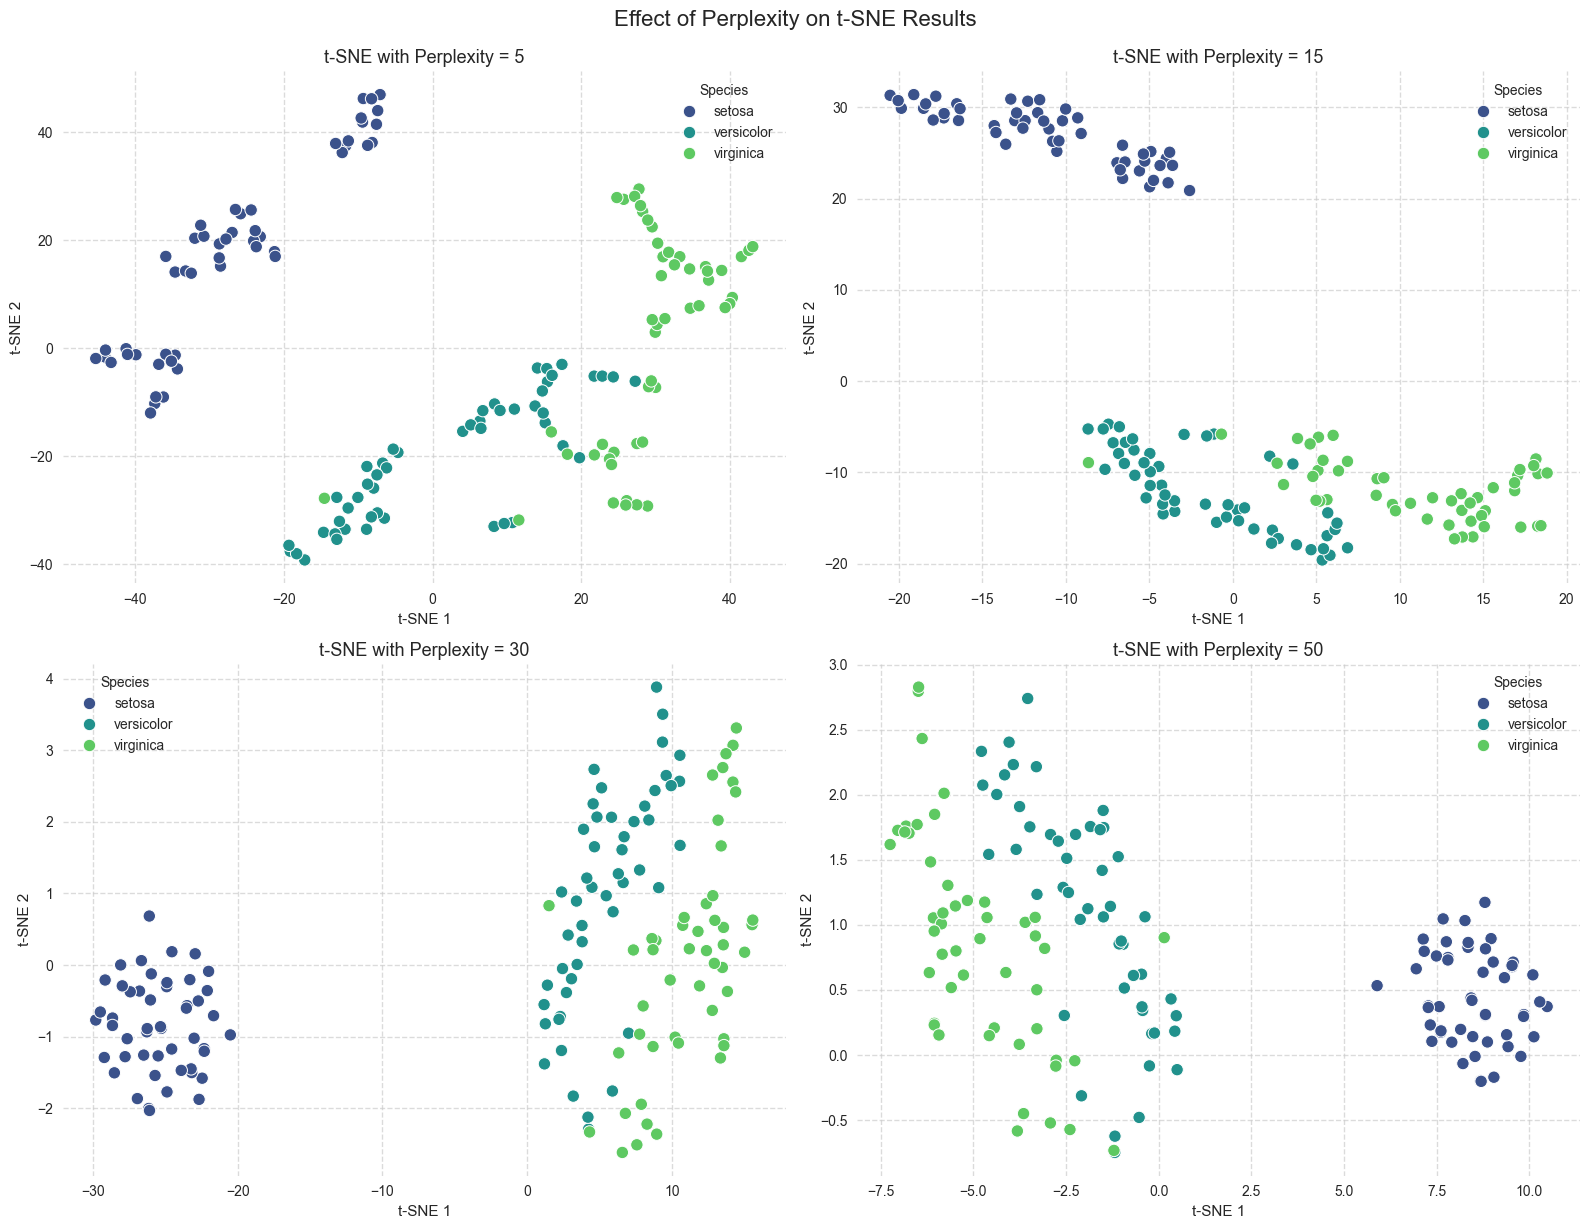

Key observations about perplexity:
- Lower perplexity (5-15): Focuses on local structure, may create more clusters
- Higher perplexity (30-50): Preserves more global structure
- There's no 'correct' value - it depends on your dataset and goals


In [30]:
# Let's explore the effect of different perplexity values on t-SNE results
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, perplexity in enumerate(perplexities):
    # Apply t-SNE with different perplexity values
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        n_iter=1000
    )
    X_tsne = tsne.fit_transform(X_scaled)
    
    # Create temporary DataFrame
    temp_df = pd.DataFrame(
        data=X_tsne, 
        columns=['t-SNE 1', 't-SNE 2']
    )
    temp_df['target'] = y
    temp_df['target_name'] = [target_names[i] for i in y]
    
    # Plot on the appropriate subplot
    sns.scatterplot(
        x='t-SNE 1', 
        y='t-SNE 2', 
        hue='target_name',
        palette='viridis',
        s=80,
        data=temp_df,
        ax=axes[i]
    )
    axes[i].set_title(f't-SNE with Perplexity = {perplexity}', fontsize=13)
    axes[i].grid(linestyle='--', alpha=0.7)
    axes[i].legend(title='Species')

plt.tight_layout()
plt.suptitle('Effect of Perplexity on t-SNE Results', fontsize=16, y=1.02)
plt.show()

print("Key observations about perplexity:")
print("- Lower perplexity (5-15): Focuses on local structure, may create more clusters")
print("- Higher perplexity (30-50): Preserves more global structure")
print("- There's no 'correct' value - it depends on your dataset and goals")

## 7. Comparing Dimensionality Reduction Techniques

Now that we've explored PCA, LDA, and t-SNE individually, let's compare them side-by-side on the Iris dataset. This will help us understand when to use each technique.

### Practical Comparison of Each Method

Let's understand when to use each method with a simple analogy:

1. **PCA**: Like taking a photo of a complex 3D object from its "best angle"
   - Preserves overall shape/variance
   - Doesn't care about different types/classes
   - Simple, fast, and well-understood

2. **LDA**: Like organizing books on shelves by their genres
   - Groups similar items together
   - Separates different categories
   - Needs to know the categories in advance

3. **t-SNE**: Like carefully unfolding an intricate origami
   - Preserves complex local structures
   - Can reveal hidden patterns
   - More computationally intensive

Below, we'll compare these techniques side by side on the same dataset:

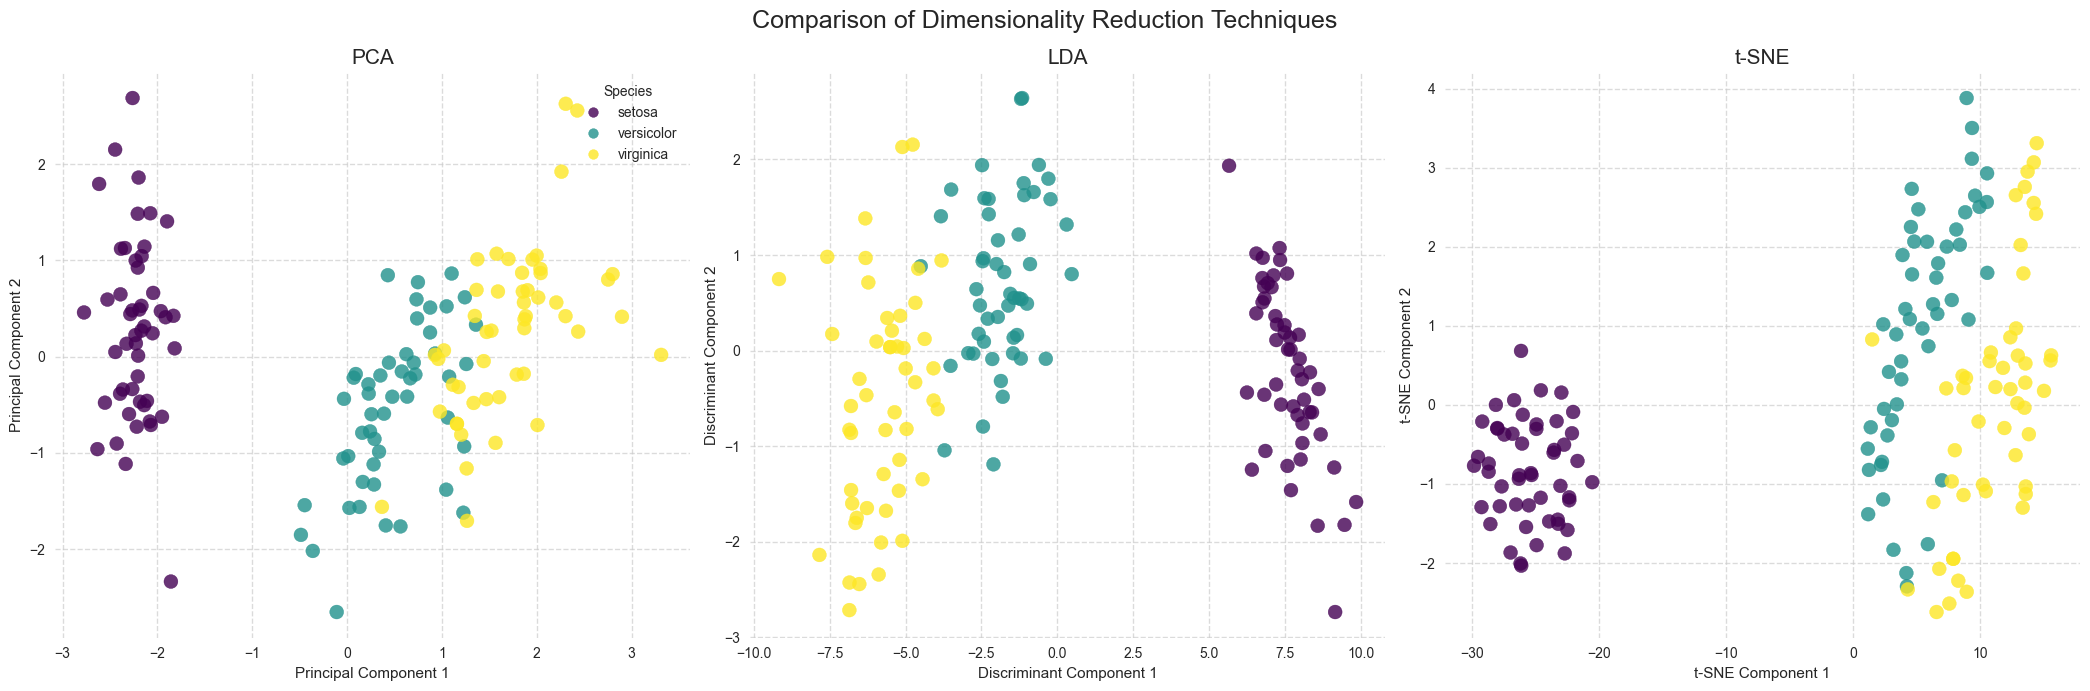

Comparing the dimensionality reduction techniques:

1. PCA:
   - Unsupervised technique (doesn't use class labels)
   - Preserves maximum variance in the data
   - Linear transformation
   - Fast to compute and deterministic
   - Good for data compression and noise reduction
   - For Iris: Explained 95.81% of variance with 2 components

2. LDA:
   - Supervised technique (uses class labels)
   - Maximizes separation between classes
   - Linear transformation
   - Can be used directly for classification
   - Limited to C-1 dimensions (where C is number of classes)

3. t-SNE:
   - Unsupervised technique
   - Non-linear transformation
   - Preserves local structure (similar points stay close)
   - Great for visualization but not for feature extraction
   - Results vary with different parameter settings
   - Computationally more expensive
   - Stochastic nature (different runs can give different results)

Recommended Use Cases:
- Use PCA for: Data compression, noise reduction, feature extra

In [31]:
# Apply all three techniques to the Iris dataset
# For fair comparison, we'll use the same random state and create 2D projections

# PCA (already done)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# LDA (already done)
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# t-SNE with a standard perplexity
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

# Plot PCA
scatter1 = axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1], 
    c=y, 
    cmap='viridis', 
    s=100, 
    alpha=0.8
)
axes[0].set_title('PCA', fontsize=15)
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].grid(linestyle='--', alpha=0.7)

# Plot LDA
scatter2 = axes[1].scatter(
    X_lda[:, 0], X_lda[:, 1], 
    c=y, 
    cmap='viridis', 
    s=100, 
    alpha=0.8
)
axes[1].set_title('LDA', fontsize=15)
axes[1].set_xlabel('Discriminant Component 1')
axes[1].set_ylabel('Discriminant Component 2')
axes[1].grid(linestyle='--', alpha=0.7)

# Plot t-SNE
scatter3 = axes[2].scatter(
    X_tsne[:, 0], X_tsne[:, 1], 
    c=y, 
    cmap='viridis', 
    s=100, 
    alpha=0.8
)
axes[2].set_title('t-SNE', fontsize=15)
axes[2].set_xlabel('t-SNE Component 1')
axes[2].set_ylabel('t-SNE Component 2')
axes[2].grid(linestyle='--', alpha=0.7)

# Add a shared legend
legend1 = axes[0].legend(
    scatter1.legend_elements()[0], 
    target_names,
    title="Species",
    loc="upper right"
)

plt.suptitle('Comparison of Dimensionality Reduction Techniques', fontsize=18, y=0.98)
plt.tight_layout()
plt.show()

# Let's summarize the differences
print("Comparing the dimensionality reduction techniques:")
print("\n1. PCA:")
print("   - Unsupervised technique (doesn't use class labels)")
print("   - Preserves maximum variance in the data")
print("   - Linear transformation")
print("   - Fast to compute and deterministic")
print("   - Good for data compression and noise reduction")
print(f"   - For Iris: Explained {sum(pca.explained_variance_ratio_)*100:.2f}% of variance with 2 components")

print("\n2. LDA:")
print("   - Supervised technique (uses class labels)")
print("   - Maximizes separation between classes")
print("   - Linear transformation")
print("   - Can be used directly for classification")
print("   - Limited to C-1 dimensions (where C is number of classes)")

print("\n3. t-SNE:")
print("   - Unsupervised technique")
print("   - Non-linear transformation")
print("   - Preserves local structure (similar points stay close)")
print("   - Great for visualization but not for feature extraction")
print("   - Results vary with different parameter settings")
print("   - Computationally more expensive")
print("   - Stochastic nature (different runs can give different results)")

print("\nRecommended Use Cases:")
print("- Use PCA for: Data compression, noise reduction, feature extraction, or as preprocessing step")
print("- Use LDA for: Classification tasks where class separation is important")
print("- Use t-SNE for: Data visualization and exploration, especially for complex non-linear data")

## Summary

In this notebook, we've explored several key dimensionality reduction techniques:

1. **Curse of Dimensionality**:
   - As dimensions increase, data becomes sparse and distance metrics break down
   - More dimensions require exponentially more samples: $(\frac{1}{density})^n$
   - Dimensionality reduction helps overcome these challenges

2. **Principal Component Analysis (PCA)**:
   - Unsupervised linear technique
   - Maximizes variance: finds directions where data varies the most
   - Key formula: $Z = XV_k$ (project data onto top eigenvectors)
   - Good for general-purpose dimensionality reduction and visualization
   - Think of it as finding the "best camera angles" to view your data

3. **Linear Discriminant Analysis (LDA)**:
   - Supervised linear technique
   - Maximizes class separation using: $S_W^{-1}S_B$
   - Great for classification tasks
   - Think of it as finding the viewpoint that best separates different groups

4. **t-SNE**:
   - Unsupervised non-linear technique
   - Preserves local structure by matching probability distributions
   - Uses t-distribution in low dimensions to avoid the "crowding problem"
   - Excellent for visualization of complex data
   - Think of it as carefully "unfolding" your high-dimensional data

### Choosing the Right Technique:

When working with high-dimensional data, consider:
- **Goal of analysis**:
  - For classification → LDA often works best
  - For visualization → t-SNE excels
  - For general data compression → PCA is efficient and simple
- **Data properties**:
  - Linear relationships → PCA or LDA
  - Complex non-linear patterns → t-SNE
- **Computational resources**:
  - Limited resources → PCA (fastest)
  - More resources → t-SNE (slowest but powerful)
- **Interpretability needs**:
  - Need clear feature importance → PCA
  - Need to understand class differences → LDA

Remember that dimensionality reduction always involves a trade-off between information loss and simplification, so choose the technique that best aligns with your specific needs!